# Chlorophyll-a Estimation

This notebook processes MODIS-Terra and MODIS-Aqua data, utilizing bands 1, 2, and 4. It computes several common band ratios. It then uses a Random Forest model to improve prediction accuracy, accounting for the optical differences between Upper Klamath Lake (shallow, turbid) and Detroit Lake (deep, clear) to achieve better transferability and seasonal pattern preservation.

In [15]:
# Import all required libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Process the MODIS 500 m MOD09GA Data using Google Earth Engine (GEE)

### Notes

1. This notebook uses a time window of 2011 - 2025. Adjust the date range if needed.
2. The code exports CSV files to the local directory.
3. Two CSV files are exported for each lake: `[Lake]_Terra.csv` and `[Lake]_Aqua.csv`.

The code extracts:

- Band 1 (Red, 620-670 nm) 
- Band 2 (NIR, 841-876 nm)
- Band 4 (Green, 545-565 nm)
- Calculated ratios: NIR/Red, Green/Red, and NDCI

After running the following GEE cell, the CSV files it produces will be used for the rest of the analysis.

The exported CSV files will contain columns:

`datetime`, `sensor`, `band1_red`, `band2_nir`, `band4_green`, `nir_red_ratio`, `green_red_ratio`, `ndci`

In [ ]:
# ============================================
# Google Earth Engine MODIS Data Extraction
# ============================================

# Import and Initialize GEE
import ee
import pandas as pd
import numpy as np
from datetime import datetime

# Authenticate and initialize GEE
ee.Authenticate()
ee.Initialize(project='ee-toddsteissberg')  # Replace with your GEE project ID

print("GEE initialized successfully!")

In [ ]:
# ============================================
# Configuration Parameters
# ============================================

CONFIG = {
    'lakes': [
        {
            'name': 'UpperKlamath',
            'lon': -121.900,
            'lat': 42.400,
            'export_prefix': 'UKL_MODIS_Multiband'
        },
        {
            'name': 'Detroit_Mid-Lake',
            'lon': -122.184,
            'lat': 44.711,
            'export_prefix': 'Detroit_Mid-Lake_MODIS_Multiband'
        },
        {
            'name': 'Detroit_Dam',
            'lon': -122.238,
            'lat': 44.706,
            'export_prefix': 'Detroit_Dam_MODIS_Multiband'
        },
        {
            'name': 'Foster',
            'lon': -122.645,
            'lat': 44.414,
            'export_prefix': 'Foster_MODIS_Multiband'
        },
        {
            'name': 'Green_Peter',
            'lon': -122.508,
            'lat': 44.472,
            'export_prefix': 'Green_Peter_MODIS_Multiband'
        }
    ],
    'start_date': '2011-01-01',
    'end_date': '2025-12-31',
    # 'roi_radius_m': 500, # Changed from 1000 m to 500 m on Aug 21, 2025
    # 'shoreline_buffer_m': 250, # Changed from 500 m to 250 m on Aug 21, 2025
    'roi_radius_m': 1000, # I changed it back to 1000 m on Aug 21, 2025. The smaller ROI and buffer resulted in too much noise.
    'shoreline_buffer_m': 500, # I changed it back to 500 m on Aug 21, 2025. The smaller ROI and buffer resulted in too much noise.
    'water_occ_threshold': 75,
    'terra_collection': 'MODIS/061/MOD09GA',
    'aqua_collection': 'MODIS/061/MYD09GA',
    'gsw_dataset': 'JRC/GSW1_4/GlobalSurfaceWater',
    'b1_red_threshold': 0.5, # Max allowed Red value
    'b2_nir_threshold': 0.7, # Max allowed NIR value
    'b4_green_threshold': 0.6, # Max allowed Green value
    'sr_scale': 1e-4
}

print("Configuration loaded")
print(f"Processing lakes: {[lake['name'] for lake in CONFIG['lakes']]}")
print(f"Date range: {CONFIG['start_date']} to {CONFIG['end_date']}")

In [ ]:
# ============================================
# Define Masking Functions
# ============================================

def mask_mod09(img):
    """
    Apply quality masks to MODIS imagery.
    Uses state_1km band for cloud, shadow, and other quality flags.
    """
    qa = img.select('state_1km')
    
    # Cloud state (bits 0-1): 0=clear, 1=cloudy, 2=mixed, 3=not set
    cloud_state = qa.bitwiseAnd(3)
    cloudy_or_mixed = cloud_state.eq(1).Or(cloud_state.eq(2))
    
    # Other quality flags
    shadow = qa.bitwiseAnd(1 << 2).neq(0)    # bit 2: cloud shadow
    cirrus = qa.bitwiseAnd(3 << 8).neq(0)    # bits 8-9: cirrus detected
    intcloud = qa.bitwiseAnd(1 << 10).neq(0) # bit 10: internal cloud
    snowice = qa.bitwiseAnd(1 << 12).neq(0)  # bit 12: snow/ice
    
    # Combine all masks
    mask = cloudy_or_mixed.Or(shadow).Or(cirrus).Or(intcloud).Or(snowice).Not()
    return img.updateMask(mask)

def build_water_mask():
    """
    Create persistent water mask from JRC Global Surface Water.
    Erodes shoreline to avoid mixed pixels.
    """
    gsw = ee.Image(CONFIG['gsw_dataset']).select('occurrence')
    water = gsw.gte(CONFIG['water_occ_threshold'])
    water_eroded = water.focal_min(
        radius=CONFIG['shoreline_buffer_m'], 
        units='meters'
    )
    return water_eroded

# Create water mask
WATER_MASK = build_water_mask()
print("Water mask created")

In [ ]:
# ============================================
# Define Feature Extraction Function
# ============================================

def extract_multiband_stats(img, roi_geom, sensor_tag):
    """
    Extract all three MODIS bands plus computed indices.
    Returns a feature with band values and metadata.
    """
    # Apply masks
    img = mask_mod09(img).updateMask(WATER_MASK)
    
    # Extract and scale bands
    red = img.select('sur_refl_b01').multiply(CONFIG['sr_scale'])
    nir = img.select('sur_refl_b02').multiply(CONFIG['sr_scale'])
    green = img.select('sur_refl_b04').multiply(CONFIG['sr_scale'])
    
    # Check for valid pixels
    valid = red.gt(0).And(nir.gt(0)).And(green.gt(0))
    
    # Stack bands for reduction
    multiband = ee.Image.cat([
        red.updateMask(valid).rename('band1_red'),
        nir.updateMask(valid).rename('band2_nir'),
        green.updateMask(valid).rename('band4_green')
    ])
    
    # Calculate band ratios for comparison
    nir_red_ratio = nir.divide(red).updateMask(valid).rename('nir_red_ratio')
    green_red_ratio = green.divide(red).updateMask(valid).rename('green_red_ratio')
    ndci = nir.subtract(red).divide(nir.add(red)).updateMask(valid).rename('ndci')
    
    # Combine all bands and indices
    all_bands = multiband.addBands([nir_red_ratio, green_red_ratio, ndci])
    
    # Reduce over ROI using median
    stats = all_bands.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=roi_geom,
        scale=500,
        maxPixels=1e9,
        bestEffort=True
    )
    
    # Create feature with properties
    props = ee.Dictionary({
        'datetime': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd HH:mm:ss'),
        # 'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
        # 'time': ee.Date(img.get('system:time_start')).format('HH:mm:ss'),
        'sensor': sensor_tag,
        'band1_red': stats.get('band1_red'),
        'band2_nir': stats.get('band2_nir'),
        'band4_green': stats.get('band4_green'),
        'nir_red_ratio': stats.get('nir_red_ratio'),
        'green_red_ratio': stats.get('green_red_ratio'),
        'ndci': stats.get('ndci')
    })
    
    return ee.Feature(None, props)

def process_collection(col_id, roi_geom, sensor_tag):
    """
    Process an entire image collection.
    """
    ic = (ee.ImageCollection(col_id)
          .filterDate(CONFIG['start_date'], CONFIG['end_date'])
          .filterBounds(roi_geom))
    
    fc = ic.map(lambda img: extract_multiband_stats(img, roi_geom, sensor_tag))
    fc = fc.filter(ee.Filter.notNull(['band1_red', 'band2_nir', 'band4_green']))
    
    return fc

print("Processing functions defined")

In [ ]:
# ============================================
# Process and Export Data
# ============================================

def reorganize_dataframe_for_export(df):
    """
    Reorganize dataframe for export, and set datetime as the index.
    This will drop the date and time columns, if they exist.
    """
    df['datetime'] = pd.to_datetime(df['datetime']) # Make sure datetime is in the proper datetime format
    df = df[['datetime', 'sensor', 'band1_red', 'band2_nir', 'band4_green', 
         'green_red_ratio', 'nir_red_ratio', 'ndci']].set_index('datetime')
    return df

def export_dataframe(modis_fc, sensor_name, lake) -> str:
    modis_rows = modis_fc.getInfo()['features']
    modis_records = [f['properties'] for f in modis_rows]
    modis_df = pd.DataFrame.from_records(modis_records)
    modis_df = reorganize_dataframe_for_export(modis_df)

    if len(modis_df) > 0:
        modis_df = modis_df.sort_values('datetime')
        modis_filename = f"{lake['export_prefix']}_{sensor_name}.csv"
        modis_df.to_csv(modis_filename, index=True)
        print(f"  Exported: {modis_filename} ({len(modis_df)} records)")
    else:
        print(f"  WARNING: No {sensor_name} data for {lake['name']}")
        modis_filename = None
    return modis_filename

In [ ]:
#============================================
# Process and export data for each lake
#============================================

exported_files = {}

for lake in CONFIG['lakes']:
    print(f"\nProcessing {lake['name']} Lake...")
    
    # Create ROI
    center = ee.Geometry.Point([lake['lon'], lake['lat']])
    roi = center.buffer(CONFIG['roi_radius_m'])
    
    # Process Terra
    print("  Processing Terra...")
    terra_fc = process_collection(CONFIG['terra_collection'], roi, 'Terra')
    terra_size = terra_fc.size().getInfo()
    print(f"    Found {terra_size} valid Terra observations")
    
    # Process Aqua
    print("  Processing Aqua...")
    aqua_fc = process_collection(CONFIG['aqua_collection'], roi, 'Aqua')
    aqua_size = aqua_fc.size().getInfo()
    print(f"    Found {aqua_size} valid Aqua observations")
    
    # Export to local CSV files
    print("  Exporting data...")
    
    # Terra and Aqua export
    terra_filename = export_dataframe(terra_fc, 'Terra', lake)
    aqua_filename = export_dataframe(aqua_fc, 'Aqua', lake)
    
    # Store filenames
    exported_files[lake['name']] = {
        'terra': terra_filename,
        'aqua': aqua_filename
    }

print("\n" + "="*50)
print("GEE data extraction complete!")
print("="*50)

In [ ]:
# ============================================
# Verify Exported Data
# ============================================

print("\nVerifying exported data...")

for lake_name, files in exported_files.items():
    print(f"\n{lake_name} Lake:")
    
    # Check Terra
    if files['terra']:
        terra_df = pd.read_csv(files['terra'])
        print(f"  Terra: {len(terra_df)} observations")
        print(f"    Date range: {terra_df['datetime'].min()} to {terra_df['datetime'].max()}")
        print(f"    Band1 (Red) range: {terra_df['band1_red'].min():.4f} - {terra_df['band1_red'].max():.4f}")
        print(f"    Band2 (NIR) range: {terra_df['band2_nir'].min():.4f} - {terra_df['band2_nir'].max():.4f}")
        print(f"    Band4 (Green) range: {terra_df['band4_green'].min():.4f} - {terra_df['band4_green'].max():.4f}")
    
    # Check Aqua
    if files['aqua']:
        aqua_df = pd.read_csv(files['aqua'])
        print(f"  Aqua: {len(aqua_df)} observations")
        print(f"    Date range: {aqua_df['datetime'].min()} to {aqua_df['datetime'].max()}")

print("\nAll data exported successfully!")
print("\nNext steps:")
print("1. Use these CSV files for the ML model training")
print("2. Match with in-situ chlorophyll data")
print("3. Train and apply the transferable models")

In [ ]:
# ============================================
# Data Quality Check
# ============================================

print("\n" + "="*50)
print("Quick Data Quality Check")
print("="*50)

lake_names = [lake['name'] for lake in CONFIG['lakes']]

for lake_name in lake_names:
    if lake_name in exported_files and exported_files[lake_name]['terra']:
        df = pd.read_csv(exported_files[lake_name]['terra'])
        
        # Check for potential issues
        print(f"\n{lake_name} Data Quality:")
        
        # Check for NaN valuesn
        nan_counts = df.isna().sum()
        if nan_counts.any():
            print("  WARNING: NaN values found:")
            print(nan_counts[nan_counts > 0])
        else:
            print("  No NaN values")
        
        # Check for outliers (simple threshold)
        outliers = (df['band1_red'] > CONFIG['b1_red_threshold']) | (df['band2_nir'] > CONFIG['b2_nir_threshold']) | (df['band4_green'] > CONFIG['b4_green_threshold'])
        if outliers.any():
            print(f"Potential outliers: {outliers.sum()} observations with very high reflectance")
        else:
            print("No obvious outliers")
        
        # Check temporal coverage
        df['date'] = pd.to_datetime(df['datetime'])
        df['year'] = df['date'].dt.year
        yearly_counts = df.groupby('year').size()
        print(f"  Observations per year:")
        print(f"    Min: {yearly_counts.min()} ({yearly_counts.idxmin()})")
        print(f"    Max: {yearly_counts.max()} ({yearly_counts.idxmax()})")
        print(f"    Mean: {yearly_counts.mean():.1f}")

## 2. Load UKL In-Situ Data

In [16]:
def load_ukl_insitu_data(file_path):
    """
    Load UKL in situ chlorophyll data from Excel file.
    Handles various date formats including Excel serial dates.
    """
    print(f"Loading UKL in situ data from: {file_path}")
    
    # Read the Excel file
    df = pd.read_excel(file_path)
    
    # Filter for chlorophyll measurements
    chl_data = df[df['CharacteristicName'] == 'Chlorophyll a'].copy()
    
    print(f"Found {len(chl_data)} chlorophyll measurements")
    
    # Process the data
    processed_data = []
    
    for _, row in chl_data.iterrows():
        try:
            # Handle date parsing
            date_value = row['ActivityStartDate']
            
            if isinstance(date_value, (int, float)):
                # Excel serial date
                date = pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(date_value))
            else:
                date = pd.to_datetime(date_value)
            
            # Get chlorophyll value
            chl_value = float(row['ResultMeasureValue'])
            if chl_value <= 0 or pd.isna(chl_value):
                continue
            
            processed_data.append({
                'datetime': date,
                'chlorophyll_a': chl_value,
                'organization': row['OrganizationIdentifier'],
                'location': row['MonitoringLocationName']
            })
            
        except Exception as e:
            continue
    
    # Create DataFrame
    insitu_df = pd.DataFrame(processed_data)
    insitu_df = insitu_df.sort_values('datetime').reset_index(drop=True)
    
    # Basic statistics
    print(f"\nData Summary:")
    print(f"Date range: {insitu_df['datetime'].min()} to {insitu_df['datetime'].max()}")
    print(f"Chlorophyll range: {insitu_df['chlorophyll_a'].min():.1f} - {insitu_df['chlorophyll_a'].max():.1f} µg/L")
    print(f"Mean: {insitu_df['chlorophyll_a'].mean():.1f} µg/L")
    print(f"Median: {insitu_df['chlorophyll_a'].median():.1f} µg/L")
    
    return insitu_df

# Load the actual data
ukl_insitu = load_ukl_insitu_data('../Data/Upper_Klamath_Lake/Klamath K.xlsx')

# Filter outliers for satellite calibration
ukl_insitu_filtered = ukl_insitu[
    (ukl_insitu['chlorophyll_a'] >= 1.0) & 
    (ukl_insitu['chlorophyll_a'] <= 500.0)
].copy()

print(f"\nFiltered to {len(ukl_insitu_filtered)} measurements for calibration")

Loading UKL in situ data from: ../Data/Upper_Klamath_Lake/Klamath K.xlsx
Found 1486 chlorophyll measurements

Data Summary:
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 0.8 - 1341.3 µg/L
Mean: 57.5 µg/L
Median: 23.9 µg/L

Filtered to 1476 measurements for calibration


## 3. Load MODIS Data and Analyze Optical Differences

In [17]:
# Load MODIS data (assuming already exported from GEE above)
print("Loading MODIS data...")

def get_modis(terra_filename: str, aqua_filename: str):
    terra = pd.read_csv(terra_filename)
    aqua = pd.read_csv(aqua_filename)
    combined = pd.concat([terra, aqua], ignore_index=True)
    combined['datetime'] = pd.to_datetime(combined['datetime'])
    combined = combined.sort_values('datetime').reset_index(drop=True)
    return combined

ukl_modis = get_modis('UKL_MODIS_Multiband_Terra.csv','UKL_MODIS_Multiband_Aqua.csv')
detroit_mid_lake_modis = get_modis('Detroit_Mid-Lake_MODIS_Multiband_Terra.csv','Detroit_Mid-Lake_MODIS_Multiband_Aqua.csv')
detroit_dam_modis = get_modis('Detroit_Dam_MODIS_Multiband_Terra.csv','Detroit_Dam_MODIS_Multiband_Aqua.csv')
foster_modis = get_modis('Foster_MODIS_Multiband_Terra.csv','Foster_MODIS_Multiband_Aqua.csv')
green_peter_modis = get_modis('Green_Peter_MODIS_Multiband_Terra.csv','Green_Peter_MODIS_Multiband_Aqua.csv')

modis_lakes = {
                'ukl': {'lake_name': 'UKL', 'modis_data': ukl_modis},
                'detroit_mid_lake': {'lake_name': 'Detroit - Mid-Lake', 'modis_data': detroit_mid_lake_modis},
                'detroit_dam': {'lake_name': 'Detroit - Dam', 'modis_data': detroit_dam_modis},
                'foster': {'lake_name': 'Foster', 'modis_data': foster_modis},
                'green_peter': {'lake_name': 'Green Peter', 'modis_data': green_peter_modis}
}

for key, values in modis_lakes.items():
    lake_name = values['lake_name']
    modis_data = values['modis_data']
    print(f"{lake_name} MODIS observations: {len(modis_data)}")

Loading MODIS data...
UKL MODIS observations: 4892
Detroit - Mid-Lake MODIS observations: 3933
Detroit - Dam MODIS observations: 3941
Foster MODIS observations: 3932
Green Peter MODIS observations: 3668


In [18]:
# ============================================
# Compute Spectral Ratios for All Lakes
# ============================================

def nir_red_ratio(modis):
    """
    Compute NIR-to-Red band ratio: b2/b1

    Args:
        modis: MODIS data set for a single lake site
    """
    modis['nir_red_calc'] = modis['band2_nir'] / modis['band1_red']
    return modis

def green_red_ratio(modis):
    """
    Compute Green-to-Red band ratio: b4/b1

    Args:
        modis: MODIS data set for a single lake site
    """
    modis['green_red_calc'] = modis['band4_green'] / modis['band1_red']
    return modis

for key, values in modis_lakes.items():
    lake_name = values['lake_name']
    modis = values['modis_data']

    # Compute band ratios
    modis = nir_red_ratio(modis) # should we operate on a copy instead?
    modis = green_red_ratio(modis) # should we operate on a copy instead?

    # Replace with updated data
    modis_lakes[key]['modis_data'] = modis

## 4. Analyze Optical Differences Between Lakes

In [19]:
# ==============================================
# Analyze optical differences between two lakes
# ==============================================

# Function to remove outliers
def remove_outliers(data, n_std=3):
    """Remove values beyond n standard deviations from mean"""
    mean = np.mean(data)
    std = np.std(data)
    return data[(data > mean - n_std*std) & (data < mean + n_std*std)]
    
def analyze_optical_properties(lake1_modis, lake2_modis, lake1_name, lake2_name):
    """
    Compare optical properties between lakes to understand transferability issues.
    Fixed version with proper histogram binning and outlier handling.
    """
    print("\n=== Optical Properties Analysis ===")
    
    # Calculate statistics
    stats = {
        'lake1_nir_red_mean': lake1_modis['nir_red_calc'].mean(),
        'lake1_green_red_mean': lake1_modis['green_red_calc'].mean(),
        'lake2_nir_red_mean': lake2_modis['nir_red_calc'].mean(),
        'lake2_green_red_mean': lake2_modis['green_red_calc'].mean(),
    }
    
    # Clean data for better visualization
    lake1_nir_red_clean = remove_outliers(lake1_modis['nir_red_calc'])
    lake1_green_red_clean = remove_outliers(lake1_modis['green_red_calc'])
    lake2_nir_red_clean = remove_outliers(lake2_modis['nir_red_calc'])
    lake2_green_red_clean = remove_outliers(lake2_modis['green_red_calc'])
    
    # Calculate statistics (on original data, not cleaned)
    stats = {
        'lake1_nir_red_mean': lake1_modis['nir_red_calc'].mean(),
        'lake1_green_red_mean': lake1_modis['green_red_calc'].mean(),
        'lake2_nir_red_mean': lake2_modis['nir_red_calc'].mean(),
        'lake2_green_red_mean': lake2_modis['green_red_calc'].mean(),
    }
    stats['nir_red_ratio'] = stats['lake2_nir_red_mean'] / stats['lake1_nir_red_mean']
    stats['green_red_ratio'] = stats['lake2_green_red_mean'] / stats['lake1_green_red_mean']
    
    print(f"\nMean Band Ratios:")
    print(f"  {lake1_name}:")
    print(f"    NIR/Red: {stats['lake1_nir_red_mean']:.3f}")
    print(f"    Green/Red: {stats['lake1_green_red_mean']:.3f}")
    print(f"  {lake2_name}:")
    print(f"    NIR/Red: {stats['lake2_nir_red_mean']:.3f}")
    print(f"    Green/Red: {stats['lake2_green_red_mean']:.3f}")
    
    print(f"\nRatio Differences ({lake2_name} / {lake1_name}):")
    print(f"  NIR/Red: {stats['nir_red_ratio']:.1f}x difference")
    print(f"  Green/Red: {stats['green_red_ratio']:.1f}x difference")
    
    # Print outlier statistics
    print(f"\nOutliers removed for visualization:")
    print(f"  {lake1_name} NIR/Red: {len(lake1_modis['nir_red_calc']) - len(lake1_nir_red_clean)} outliers")
    print(f"  {lake2_name} NIR/Red: {len(lake2_modis['nir_red_calc']) - len(lake2_nir_red_clean)} outliers")
    
    # Visualization with improved binning
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # NIR/Red distributions - with adaptive binning
    ax = axes[0, 0]
    
    # Create adaptive bins for each dataset
    lake1_nir_bins = np.linspace(lake1_nir_red_clean.min(), lake1_nir_red_clean.max(), 30)
    lake2_nir_bins = np.linspace(lake2_nir_red_clean.min(), lake2_nir_red_clean.max(), 50)
    
    # Plot histograms with dataset-specific bins
    n1, bins1, patches1 = ax.hist(lake1_nir_red_clean, bins=lake1_nir_bins, alpha=0.6, 
                                   label=f'{lake1_name} (n={len(lake1_nir_red_clean)})', 
                                   color='blue', density=True, edgecolor='black')
    n2, bins2, patches2 = ax.hist(lake2_nir_red_clean, bins=lake2_nir_bins, alpha=0.6, 
                                   label=f'{lake2_name} (n={len(lake2_nir_red_clean)})', 
                                   color='red', density=True, edgecolor='black')
    
    # Add mean lines
    ax.axvline(stats['lake1_nir_red_mean'], color='darkblue', linestyle='--', linewidth=2, label='{lake1_name} mean')
    ax.axvline(stats['lake2_nir_red_mean'], color='darkred', linestyle='--', linewidth=2, label='{lake2_name} mean')
    
    ax.set_xlabel('NIR/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'NIR/Red Distribution ({stats["nir_red_ratio"]:.1f}x difference)\nPoor Transferability')
    ax.legend()

    # Let matplotlib auto-scale x-axis or set reasonable limits based on data
    ax.set_xlim(min(lake1_nir_red_clean.min(), lake2_nir_red_clean.min()) * 0.9,
                max(lake1_nir_red_clean.max(), lake2_nir_red_clean.max()) * 1.1)
    ax.grid(True, alpha=0.3)
    
    # Green/Red distributions - with adaptive binning
    ax = axes[0, 1]
    
    # Create adaptive bins for each dataset
    lake1_green_bins = np.linspace(lake1_green_red_clean.min(), lake1_green_red_clean.max(), 30)
    lake2_green_bins = np.linspace(lake2_green_red_clean.min(), lake2_green_red_clean.max(), 50)
    
    # Plot histograms with dataset-specific bins
    ax.hist(lake1_green_red_clean, bins=lake1_green_bins, alpha=0.6, 
            label=f'{lake1_name} (n={len(lake1_green_red_clean)})', 
            color='blue', density=True, edgecolor='black')
    ax.hist(lake2_green_red_clean, bins=lake2_green_bins, alpha=0.6, 
            label=f'{lake2_name} (n={len(lake2_green_red_clean)})', 
            color='red', density=True, edgecolor='black')
    
    # Add mean lines
    ax.axvline(stats['lake1_green_red_mean'], color='darkblue', linestyle='--', linewidth=2, label='{lake1_name} mean')
    ax.axvline(stats['lake2_green_red_mean'], color='darkred', linestyle='--', linewidth=2, label='{lake2_name} mean')
    
    ax.set_xlabel('Green/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'Green/Red Distribution ({stats["green_red_ratio"]:.1f}x difference)\nGood Transferability')
    ax.legend()
    # Adaptive x-axis limits
    ax.set_xlim(min(lake1_green_red_clean.min(), lake2_green_red_clean.min()) * 0.9,
                max(lake1_green_red_clean.max(), lake2_green_red_clean.max()) * 1.1)
    ax.grid(True, alpha=0.3)
    
    # Time series comparison - NIR/Red (unchanged)
    ax = axes[1, 0]
    lake1_monthly = lake1_modis.groupby(lake1_modis['datetime'].dt.month)['nir_red_calc'].mean()
    lake2_monthly = lake2_modis.groupby(lake2_modis['datetime'].dt.month)['nir_red_calc'].mean()
    ax.plot(lake1_monthly.index, lake1_monthly.values, 'b-o', label='{lake1_name}', linewidth=2)
    ax.plot(lake2_monthly.index, lake2_monthly.values, 'r-o', label='{lake2_name}', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('Seasonal NIR/Red Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Time series comparison - Green/Red (unchanged)
    ax = axes[1, 1]
    lake1_monthly = lake1_modis.groupby(lake1_modis['datetime'].dt.month)['green_red_calc'].mean()
    lake2_monthly = lake2_modis.groupby(lake2_modis['datetime'].dt.month)['green_red_calc'].mean()
    ax.plot(lake1_monthly.index, lake1_monthly.values, 'b-o', label='{lake1_name}', linewidth=2)
    ax.plot(lake2_monthly.index, lake2_monthly.values, 'r-o', label='{lake2_name}', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Seasonal Green/Red Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('optical_properties_analysis_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional diagnostic information
    print(f"\nDistribution ranges (after outlier removal):")
    print(f"  {lake1_name} NIR/Red: {lake1_nir_red_clean.min():.3f} - {lake1_nir_red_clean.max():.3f}")
    print(f"  {lake2_name} NIR/Red: {lake2_nir_red_clean.min():.3f} - {lake2_nir_red_clean.max():.3f}")
    print(f"  {lake1_name} Green/Red: {lake1_green_red_clean.min():.3f} - {lake1_green_red_clean.max():.3f}")
    print(f"  {lake2_name} Green/Red: {lake2_green_red_clean.min():.3f} - {lake2_green_red_clean.max():.3f}")
    
    return stats



=== Optical Properties Analysis ===

Mean Band Ratios:
  UKL:
    NIR/Red: 0.643
    Green/Red: 1.485
  Detroit - Mid-Lake:
    NIR/Red: 4.751
    Green/Red: 1.515

Ratio Differences (Detroit - Mid-Lake / UKL):
  NIR/Red: 7.4x difference
  Green/Red: 1.0x difference

Outliers removed for visualization:
  UKL NIR/Red: 19 outliers
  Detroit - Mid-Lake NIR/Red: 33 outliers


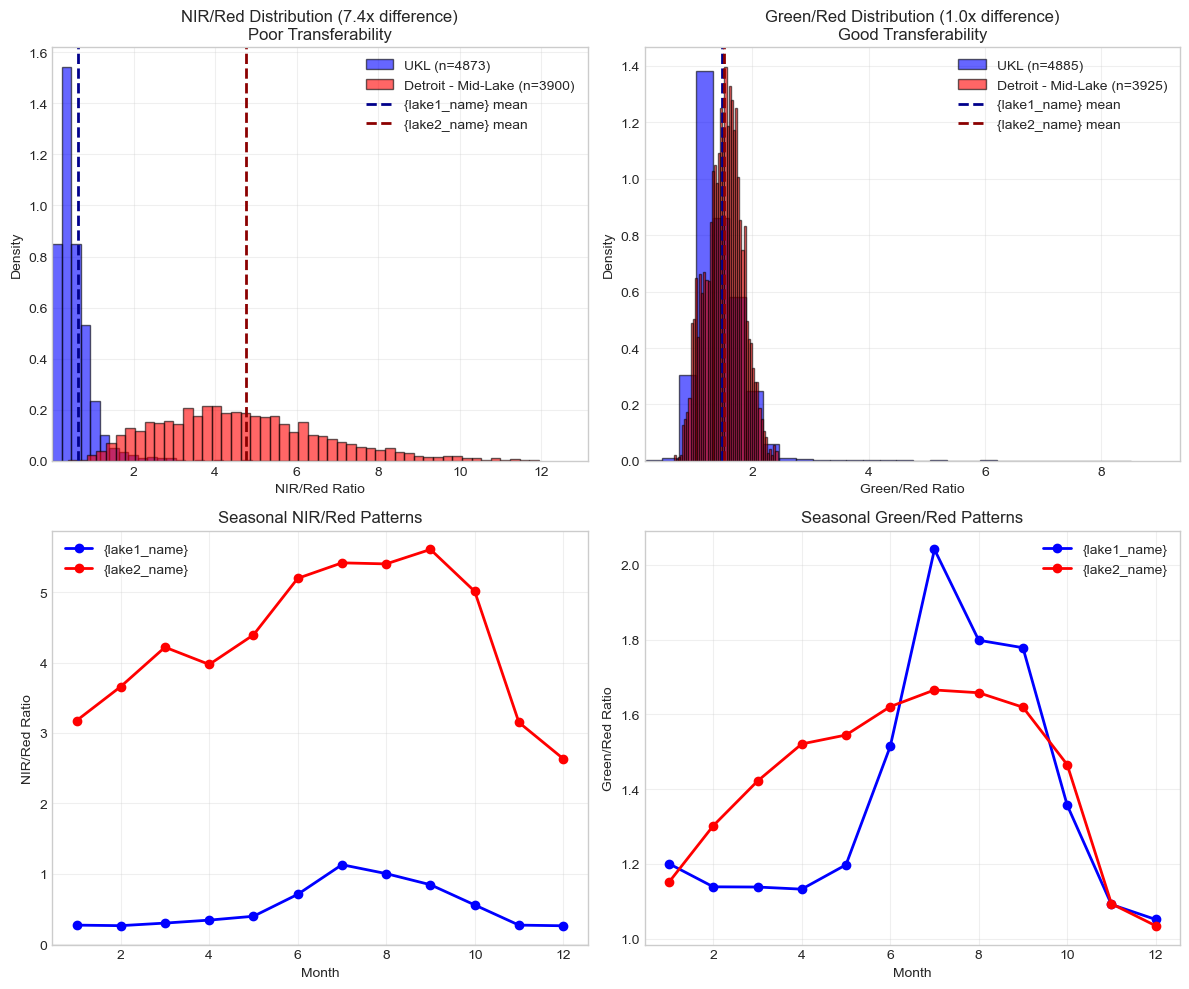


Distribution ranges (after outlier removal):
  UKL NIR/Red: 0.004 - 6.769
  Detroit - Mid-Lake NIR/Red: 0.381 - 11.939
  UKL Green/Red: 0.167 - 8.500
  Detroit - Mid-Lake Green/Red: 0.646 - 2.433


In [20]:
#===========================================================
# Compute Optical Statistics on UKL and Detroit - Mid-Lake
#===========================================================

lake1_name = modis_lakes['ukl']['lake_name']
lake1_modis = modis_lakes['ukl']['modis_data']
lake2_name = modis_lakes['detroit_mid_lake']['lake_name']
lake2_modis = modis_lakes['detroit_mid_lake']['modis_data']

optical_stats = analyze_optical_properties(lake1_modis, lake2_modis, lake1_name, lake2_name)

## 3. Match MODIS and In-Situ Data

In [23]:
def match_modis_insitu(modis_df, insitu_df, temporal_window_hours=120):
    """
    Match MODIS observations with in-situ measurements.
    """
    matched_data = []
    temporal_window = timedelta(hours=temporal_window_hours)
    
    for _, insitu_row in insitu_df.iterrows():
        insitu_time = insitu_row['datetime']
        
        # Find MODIS observations within temporal window
        time_diff = abs(modis_df['datetime'] - insitu_time)
        close_modis = modis_df[time_diff <= temporal_window]
        
        if len(close_modis) > 0:
            # Use closest MODIS observation
            closest_idx = time_diff[close_modis.index].argmin()
            modis_row = close_modis.iloc[closest_idx]
            
            matched_data.append({
                'datetime': insitu_time,
                'modis_datetime': modis_row['datetime'],
                'time_diff_hours': time_diff[close_modis.index].iloc[closest_idx].total_seconds() / 3600,
                'sensor': modis_row['sensor'],
                'band1_red': modis_row['band1_red'],
                'band2_nir': modis_row['band2_nir'],
                'band4_green': modis_row['band4_green'],
                'chlorophyll_a': insitu_row['chlorophyll_a']
            })
    
    matched_df = pd.DataFrame(matched_data)
    return matched_df


In [24]:
#========================================================
# Match MODIS and In-Situ Data at Calibration Site: UKL
#========================================================

print("Matching MODIS and in-situ observations...")
matched_data = match_modis_insitu(ukl_modis, ukl_insitu_filtered, temporal_window_hours=120)

print(f"\nMatched {len(matched_data)} MODIS-insitu pairs")
print(f"Average time difference: {matched_data['time_diff_hours'].mean():.2f} hours")
print(f"Chlorophyll range in matched data: {matched_data['chlorophyll_a'].min():.1f} - {matched_data['chlorophyll_a'].max():.1f} µg/L")

# Add calculated ratios
matched_data['nir_red_ratio'] = matched_data['band2_nir'] / matched_data['band1_red']
matched_data['green_red_ratio'] = matched_data['band4_green'] / matched_data['band1_red']

Matching MODIS and in-situ observations...

Matched 1443 MODIS-insitu pairs
Average time difference: 9.83 hours
Chlorophyll range in matched data: 1.6 - 488.0 µg/L


## 4. Develop Transferable Models

### Simple Ratio Model

In [25]:
# Calibrate simple ratio models to understand the problem
def calibrate_ratio_model(ratio_values, chla_values, model_name):
    """
    Calibrate a simple ratio-based model.
    """
    # Remove invalid values
    mask = (ratio_values > 0) & (chla_values > 0) & np.isfinite(ratio_values) & np.isfinite(chla_values)
    ratio_clean = ratio_values[mask]
    chla_clean = chla_values[mask]
    
    # Log transform
    log_ratio = np.log10(ratio_clean)
    log_chla = np.log10(chla_clean)
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_ratio, log_chla)
    
    # Calculate predictions
    pred_log = slope * log_ratio + intercept
    pred = 10**pred_log
    
    # Metrics
    r2 = r2_score(chla_clean, pred)
    rmse = np.sqrt(mean_squared_error(chla_clean, pred))
    
    print(f"\n{model_name} Model Calibration:")
    print(f"  Equation: log10(Chl-a) = {slope:.3f} * log10(ratio) + {intercept:.3f}")
    print(f"  R² = {r2:.3f}, RMSE = {rmse:.2f} µg/L")
    print(f"  N = {len(chla_clean)} samples")
    
    return {'a': slope, 'b': intercept, 'r2': r2, 'rmse': rmse, 'n': len(chla_clean)}

# Calibrate both ratio models
nir_red_model = calibrate_ratio_model(
    matched_data['nir_red_ratio'].values,
    matched_data['chlorophyll_a'].values,
    'NIR/Red'
)

green_red_model = calibrate_ratio_model(
    matched_data['green_red_ratio'].values,
    matched_data['chlorophyll_a'].values,
    'Green/Red'
)


NIR/Red Model Calibration:
  Equation: log10(Chl-a) = 0.780 * log10(ratio) + 1.710
  R² = -0.002, RMSE = 67.01 µg/L
  N = 1443 samples

Green/Red Model Calibration:
  Equation: log10(Chl-a) = 2.744 * log10(ratio) + 1.119
  R² = 0.094, RMSE = 63.71 µg/L
  N = 1443 samples


### Random Forest Model

In [26]:
class TransferableRFModel:
    """
    Random Forest that emphasizes transferable features.
    """
    def __init__(self, n_estimators=150):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=8,  # Shallow trees for better generalization
            min_samples_leaf=15,  # Prevent overfitting
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        self.scaler = RobustScaler()
        self.feature_names = []
        
    def create_features(self, band1, band2, band4, dates=None):
        """
        Create features emphasizing Green/Red combinations.
        """
        features = []
        self.feature_names = []
        
        # Primary features (Green/Red based - good transferability)
        green_red = band4 / band1
        features.append(green_red.reshape(-1, 1))
        self.feature_names.append('Green/Red')
        
        features.append(np.log10(green_red + 0.001).reshape(-1, 1))
        self.feature_names.append('log(Green/Red)')
        
        # Green-based normalized difference
        grnd = (band4 - band1) / (band4 + band1)
        features.append(grnd.reshape(-1, 1))
        self.feature_names.append('GRND')
        
        # Raw green band (important for seasonal patterns)
        features.append(band4.reshape(-1, 1))
        self.feature_names.append('Green_band')
        
        # Secondary features (use with caution)
        # NIR/Green has moderate transferability
        nir_green = band2 / band4
        features.append(nir_green.reshape(-1, 1))
        self.feature_names.append('NIR/Green')
        
        # Modified three-band emphasizing green
        three_band = (1/band1 - 1/band4) * band4
        features.append(three_band.reshape(-1, 1))
        self.feature_names.append('Green_3band')
        
        # Seasonal features
        if dates is not None:
            dates_series = pd.to_datetime(dates)
            doy = dates_series.dt.dayofyear
            features.append(np.sin(2 * np.pi * doy / 365).values.reshape(-1, 1))
            features.append(np.cos(2 * np.pi * doy / 365).values.reshape(-1, 1))
            self.feature_names.extend(['DOY_sin', 'DOY_cos'])
        
        # Minimal use of NIR/Red (poor transferability)
        # Include but with limited influence
        nir_red_log = np.log10(band2 / band1 + 0.001)
        features.append(nir_red_log.reshape(-1, 1))
        self.feature_names.append('log(NIR/Red)_limited')
        
        X = np.hstack(features)
        return np.nan_to_num(X, nan=0, posinf=0, neginf=0)
    
    def fit(self, band1, band2, band4, chla, dates=None):
        """
        Train the model.
        """
        X = self.create_features(band1, band2, band4, dates)
        y = np.sqrt(chla)  # Square root transformation
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        # Scale and train
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        self.model.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_pred = self.model.predict(X_test_scaled)
        y_test_actual = y_test ** 2
        y_pred_actual = y_pred ** 2
        
        r2 = r2_score(y_test_actual, y_pred_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
        
        print(f"\nTransferable RF Model Performance:")
        print(f"  R² = {r2:.3f}")
        print(f"  RMSE = {rmse:.2f} µg/L")
        
        # Feature importance
        print("\nTop Features:")
        for idx in np.argsort(self.model.feature_importances_)[::-1][:5]:
            print(f"  {self.feature_names[idx]}: {self.model.feature_importances_[idx]:.3f}")
        
        return self
    
    def predict(self, band1, band2, band4, dates=None):
        """
        Make predictions.
        """
        X = self.create_features(band1, band2, band4, dates)
        X_scaled = self.scaler.transform(X)
        y_pred = self.model.predict(X_scaled)
        return y_pred ** 2

In [27]:
#===================================
# Train the transferable RF model
#===================================

print("Training Transferable Random Forest Model...")
rf_model = TransferableRFModel()
rf_model = rf_model.fit(
    matched_data['band1_red'].values,
    matched_data['band2_nir'].values,
    matched_data['band4_green'].values,
    matched_data['chlorophyll_a'].values,
    matched_data['datetime']
)

Training Transferable Random Forest Model...

Transferable RF Model Performance:
  R² = 0.481
  RMSE = 53.11 µg/L

Top Features:
  log(Green/Red): 0.183
  GRND: 0.183
  Green/Red: 0.175
  Green_3band: 0.130
  log(NIR/Red)_limited: 0.097


## 5. Apply All Models to All Lakes

In [28]:
def apply_models(lake_modis, nir_red_model, green_red_model, rf_model, lake_name):
    """
    Apply all models to Detroit Lake data.
    """
    
    # NIR/Red predictions
    nir_red_ratio = lake_modis['band2_nir'] / lake_modis['band1_red']
    log_pred = nir_red_model['a'] * np.log10(nir_red_ratio) + nir_red_model['b']
    lake_modis['chl_nir_red'] = 10 ** log_pred
    
    # Green/Red predictions
    green_red_ratio = lake_modis['band4_green'] / lake_modis['band1_red']
    log_pred = green_red_model['a'] * np.log10(green_red_ratio) + green_red_model['b']
    lake_modis['chl_green_red'] = 10 ** log_pred
    
    # Random Forest predictions
    lake_modis['chl_rf'] = rf_model.predict(
        lake_modis['band1_red'].values,
        lake_modis['band2_nir'].values,
        lake_modis['band4_green'].values,
        lake_modis['datetime']
    )

    # Summary statistics
    print(f"\n=== {lake_name} Prediction Summary ===")

    print(f"NIR/Red Model:")
    print(f"  Mean: {lake_modis['chl_nir_red'].mean():.1f} µg/L")
    print(f"  Range: {lake_modis['chl_nir_red'].min():.1f} - {lake_modis['chl_nir_red'].max():.1f} µg/L")

    print(f"\nGreen/Red Model:")
    print(f"  Mean: {lake_modis['chl_green_red'].mean():.1f} µg/L")
    print(f"  Range: {lake_modis['chl_green_red'].min():.1f} - {lake_modis['chl_green_red'].max():.1f} µg/L")

    print(f"\nRandom Forest Model:")
    print(f"  Mean: {lake_modis['chl_rf'].mean():.1f} µg/L")
    print(f"  Range: {lake_modis['chl_rf'].min():.1f} - {lake_modis['chl_rf'].max():.1f} µg/L")
    
    return lake_modis


In [29]:
#============================================
# Apply all models to all lakes
#============================================

for key, values in modis_lakes.items():
    lake_name = values['lake_name']
    lake_modis = values['modis_data']
    modis_with_predictions = apply_models(lake_modis, nir_red_model, green_red_model, rf_model, lake_name)
    modis_lakes[key]['modis_data'] = modis_with_predictions  # Update the MODIS data in the dictionary


=== UKL Prediction Summary ===
NIR/Red Model:
  Mean: 32.9 µg/L
  Range: 0.7 - 2175.7 µg/L

Green/Red Model:
  Mean: 2392.8 µg/L
  Range: 0.1 - 6372608.7 µg/L

Random Forest Model:
  Mean: 46.5 µg/L
  Range: 6.9 - 176.5 µg/L

=== Detroit - Mid-Lake Prediction Summary ===
NIR/Red Model:
  Mean: 169.6 µg/L
  Range: 24.1 - 1112.3 µg/L

Green/Red Model:
  Mean: 45.5 µg/L
  Range: 0.4 - 945.5 µg/L

Random Forest Model:
  Mean: 64.1 µg/L
  Range: 10.2 - 122.3 µg/L

=== Detroit - Dam Prediction Summary ===
NIR/Red Model:
  Mean: 176.9 µg/L
  Range: 50.2 - 4628.0 µg/L

Green/Red Model:
  Mean: 137.2 µg/L
  Range: 0.5 - 399238.4 µg/L

Random Forest Model:
  Mean: 55.0 µg/L
  Range: 10.4 - 124.1 µg/L

=== Foster Prediction Summary ===
NIR/Red Model:
  Mean: 103.5 µg/L
  Range: 12.9 - 745.2 µg/L

Green/Red Model:
  Mean: 64.5 µg/L
  Range: 5.1 - 1649.7 µg/L

Random Forest Model:
  Mean: 72.8 µg/L
  Range: 8.3 - 133.5 µg/L

=== Green Peter Prediction Summary ===
NIR/Red Model:
  Mean: 93.9 µg/L
 

In [32]:
# Analyze seasonal patterns for all models
def plot_seasonal_comparison(predictions_df, lake_name):
    """
    Compare seasonal patterns across all models.
    """
    # Add temporal features
    predictions_df['month'] = pd.to_datetime(predictions_df['datetime']).dt.month
    predictions_df['year'] = pd.to_datetime(predictions_df['datetime']).dt.year
    predictions_df['doy'] = pd.to_datetime(predictions_df['datetime']).dt.dayofyear
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    models = [('chl_nir_red', 'NIR/Red Model', 'red'), ('chl_green_red', 'Green/Red Model', 'green'), ('chl_rf', 'Random Forest Model', 'blue')]
    
    for idx, (col, model_name, color) in enumerate(models):
        # Monthly averages
        ax = axes[idx, 0]
        monthly = predictions_df.groupby('month')[col].agg(['mean', 'std'])
        ax.errorbar(monthly.index, monthly['mean'], yerr=monthly['std'], 
                   marker='o', color=color, capsize=5, linewidth=2)
        ax.set_xlabel('Month')
        ax.set_ylabel('Chlorophyll-a (µg/L)')
        ax.set_title(f'{lake_name}, {model_name} - Monthly Averages')
        ax.grid(True, alpha=0.3)
        
        # Fix y-axis scaling to show full error bars
        # Calculate the maximum extent needed (mean + std)
        max_extent = (monthly['mean'] + monthly['std']).max()
        min_extent = max(0, (monthly['mean'] - monthly['std']).min())  # Don't go below 0
        y_padding = 0.1 * (max_extent - min_extent)  # Add 10% padding
        ax.set_ylim(min_extent - y_padding, max_extent + y_padding)
        
        # Time series
        ax = axes[idx, 1]
        # Last 3 years:
        # recent_data = predictions_df[predictions_df['year'] >= predictions_df['year'].max() - 2]
        # All data:
        recent_data = predictions_df.copy()
        
        # Plot with rolling average
        recent_data_sorted = recent_data.sort_values('datetime')
        ax.scatter(recent_data_sorted['datetime'], recent_data_sorted[col], 
                  alpha=0.3, s=10, color=color)
        
        # Add 30-day rolling average
        rolling_mean = recent_data_sorted.set_index('datetime')[col].rolling('30D').mean()
        ax.plot(rolling_mean.index, rolling_mean.values, color=color, linewidth=2)
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Chlorophyll-a (µg/L)')
        ax.set_title(f'{lake_name}, {model_name} (points: predictions; line: 30-day rolling average)')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max(100, recent_data[col].quantile(0.95) * 1.2))
        
        # Rotate x labels
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(f'{lake_name}_seasonal_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print seasonal statistics
    print("\n=== Seasonal Pattern Analysis ===")
    seasons = {
        'Winter': [12, 1, 2],
        'Spring': [3, 4, 5],
        'Summer': [6, 7, 8],
        'Fall': [9, 10, 11]
    }
    
    for col, name, _ in models:
        print(f"\n{name}:")
        for season, months in seasons.items():
            season_data = predictions_df[predictions_df['month'].isin(months)][col]
            print(f"  {season}: {season_data.mean():.1f} ± {season_data.std():.1f} µg/L")

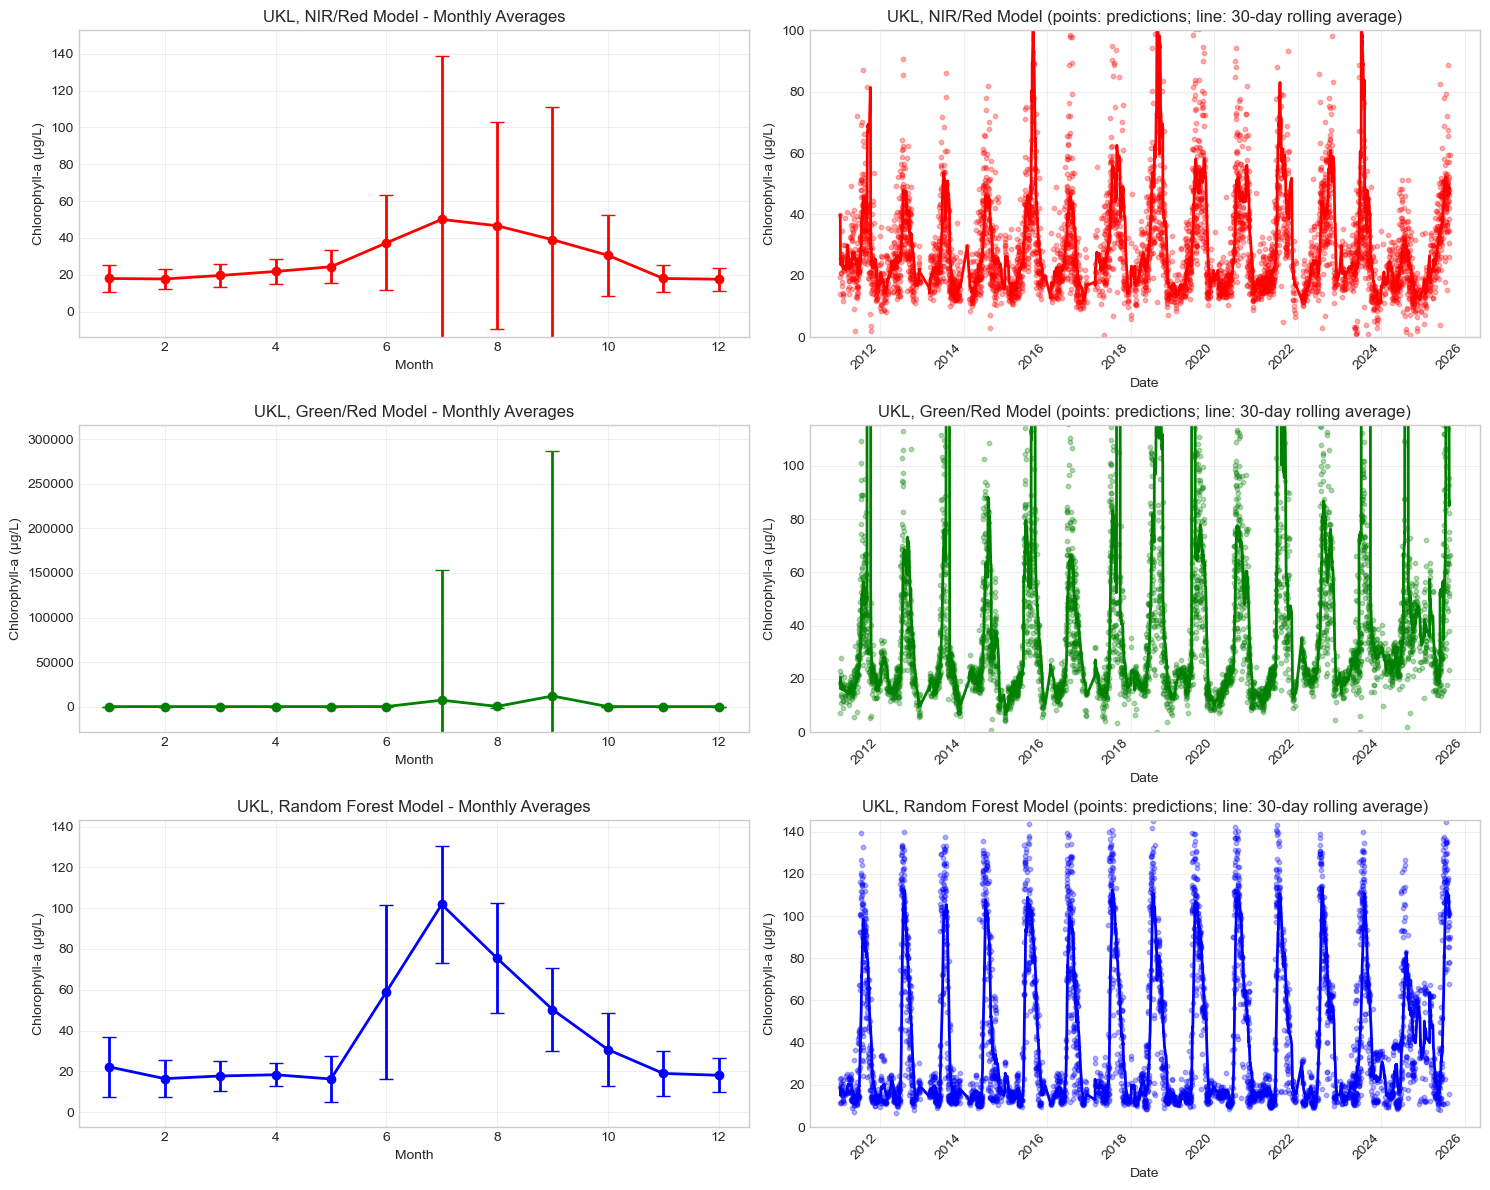


=== Seasonal Pattern Analysis ===

NIR/Red Model:
  Winter: 17.8 ± 6.3 µg/L
  Spring: 22.3 ± 7.9 µg/L
  Summer: 45.0 ± 64.5 µg/L
  Fall: 31.5 ± 49.3 µg/L

Green/Red Model:
  Winter: 19.7 ± 9.7 µg/L
  Spring: 20.9 ± 27.0 µg/L
  Summer: 2802.5 ± 89652.3 µg/L
  Fall: 5020.1 ± 178188.4 µg/L

Random Forest Model:
  Winter: 18.4 ± 11.0 µg/L
  Spring: 17.3 ± 8.7 µg/L
  Summer: 80.1 ± 37.8 µg/L
  Fall: 36.5 ± 21.7 µg/L


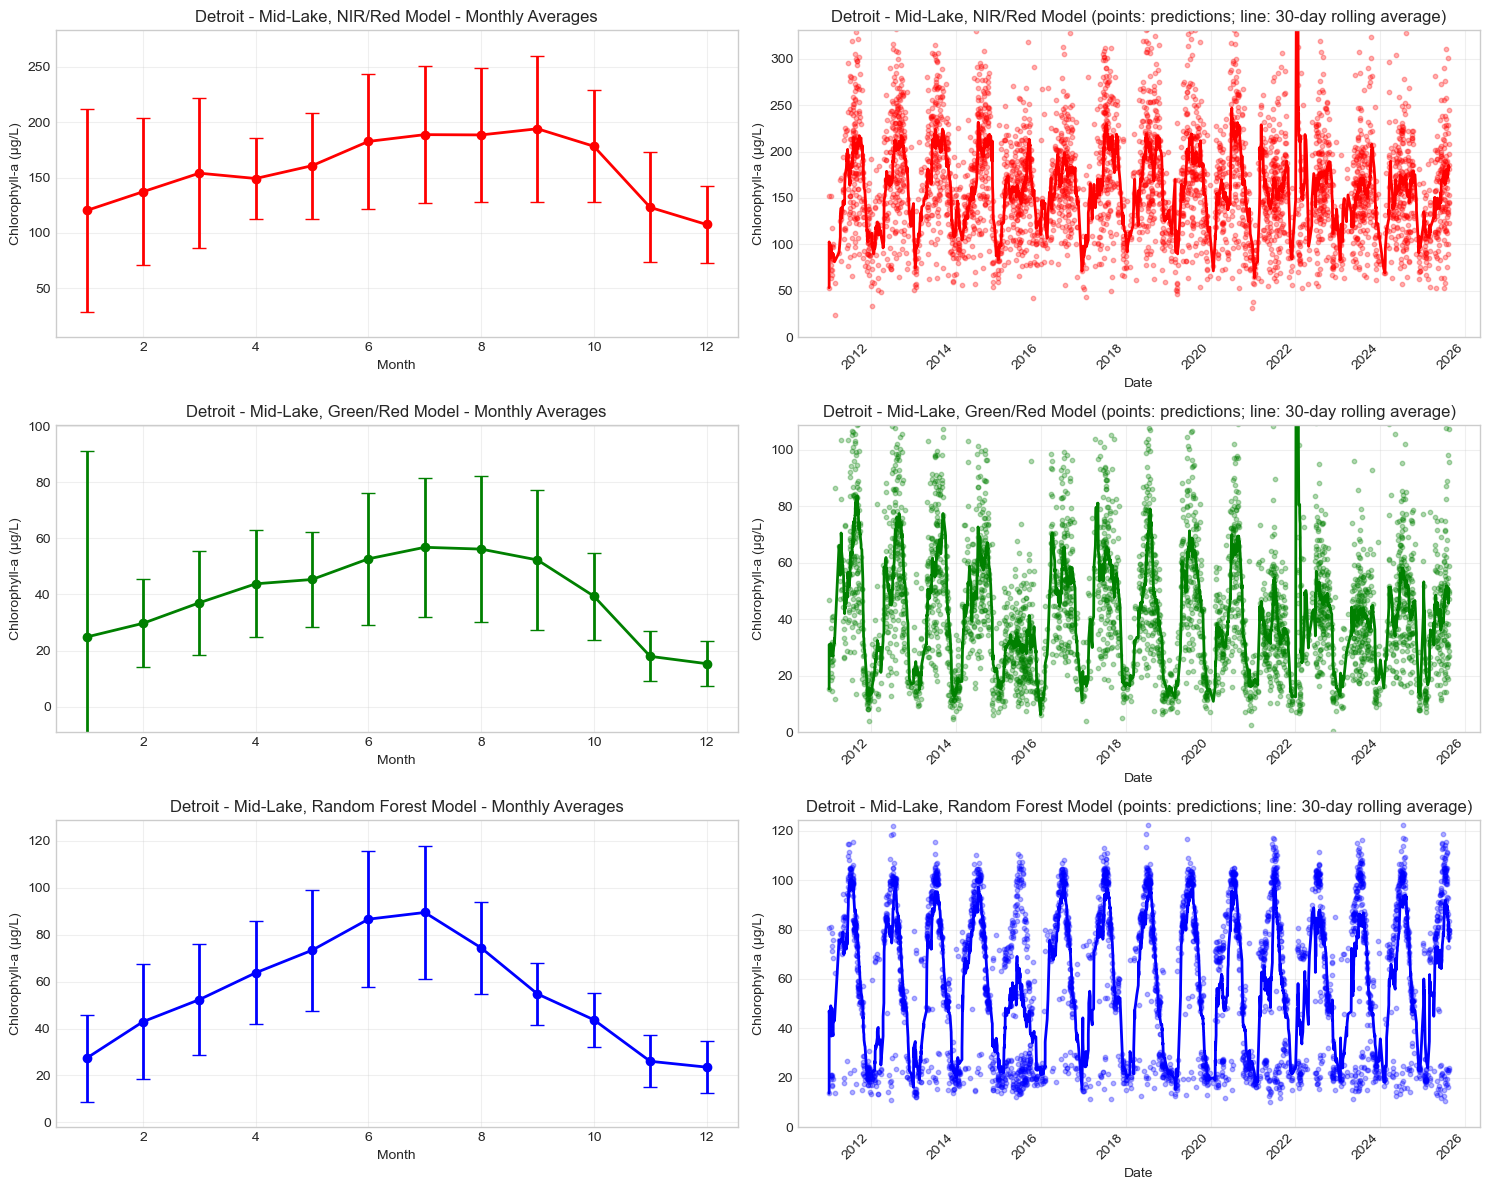


=== Seasonal Pattern Analysis ===

NIR/Red Model:
  Winter: 120.9 ± 71.6 µg/L
  Spring: 155.7 ± 50.7 µg/L
  Summer: 187.2 ± 61.2 µg/L
  Fall: 174.1 ± 63.4 µg/L

Green/Red Model:
  Winter: 23.1 ± 43.8 µg/L
  Spring: 42.9 ± 18.3 µg/L
  Summer: 55.6 ± 25.0 µg/L
  Fall: 40.7 ± 23.2 µg/L

Random Forest Model:
  Winter: 30.4 ± 20.0 µg/L
  Spring: 65.5 ± 25.6 µg/L
  Summer: 83.6 ± 26.7 µg/L
  Fall: 45.0 ± 16.3 µg/L


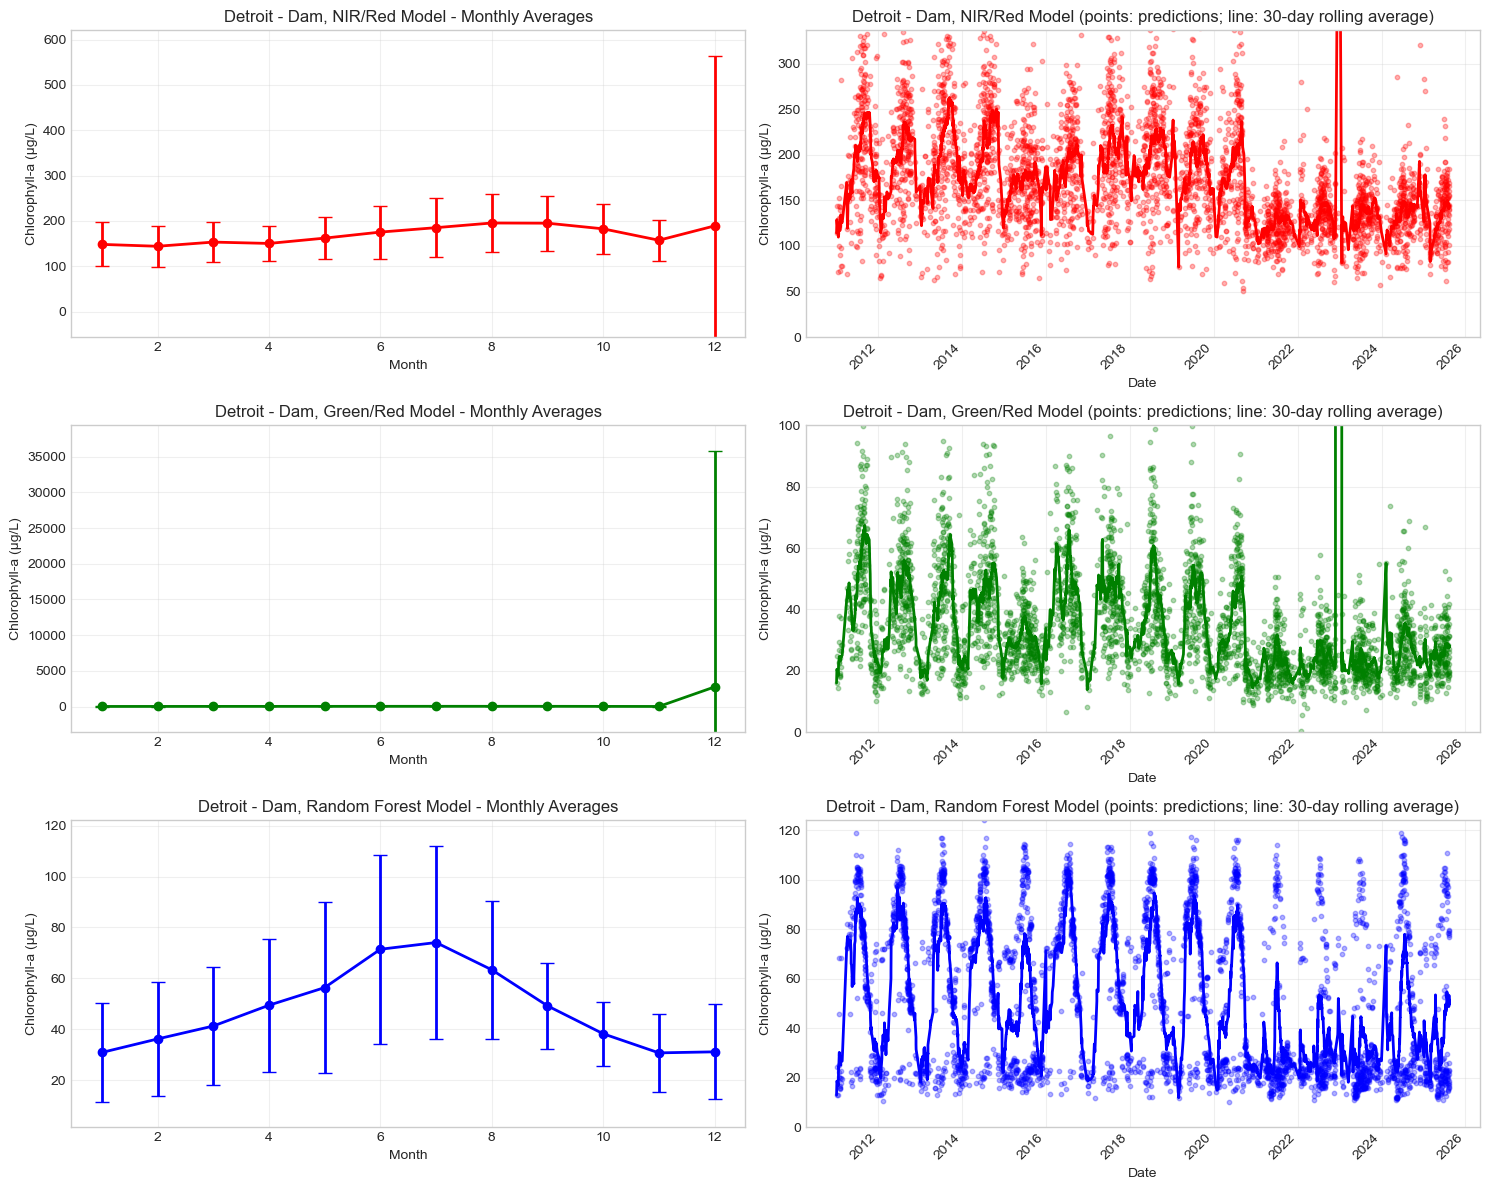


=== Seasonal Pattern Analysis ===

NIR/Red Model:
  Winter: 160.1 ± 215.4 µg/L
  Spring: 156.5 ± 44.2 µg/L
  Summer: 186.3 ± 63.4 µg/L
  Fall: 183.2 ± 57.3 µg/L

Green/Red Model:
  Winter: 893.6 ± 18633.7 µg/L
  Spring: 32.7 ± 13.8 µg/L
  Summer: 41.5 ± 19.3 µg/L
  Fall: 34.0 ± 16.4 µg/L

Random Forest Model:
  Winter: 32.4 ± 20.1 µg/L
  Spring: 50.9 ± 29.8 µg/L
  Summer: 69.7 ± 34.7 µg/L
  Fall: 41.6 ± 16.8 µg/L


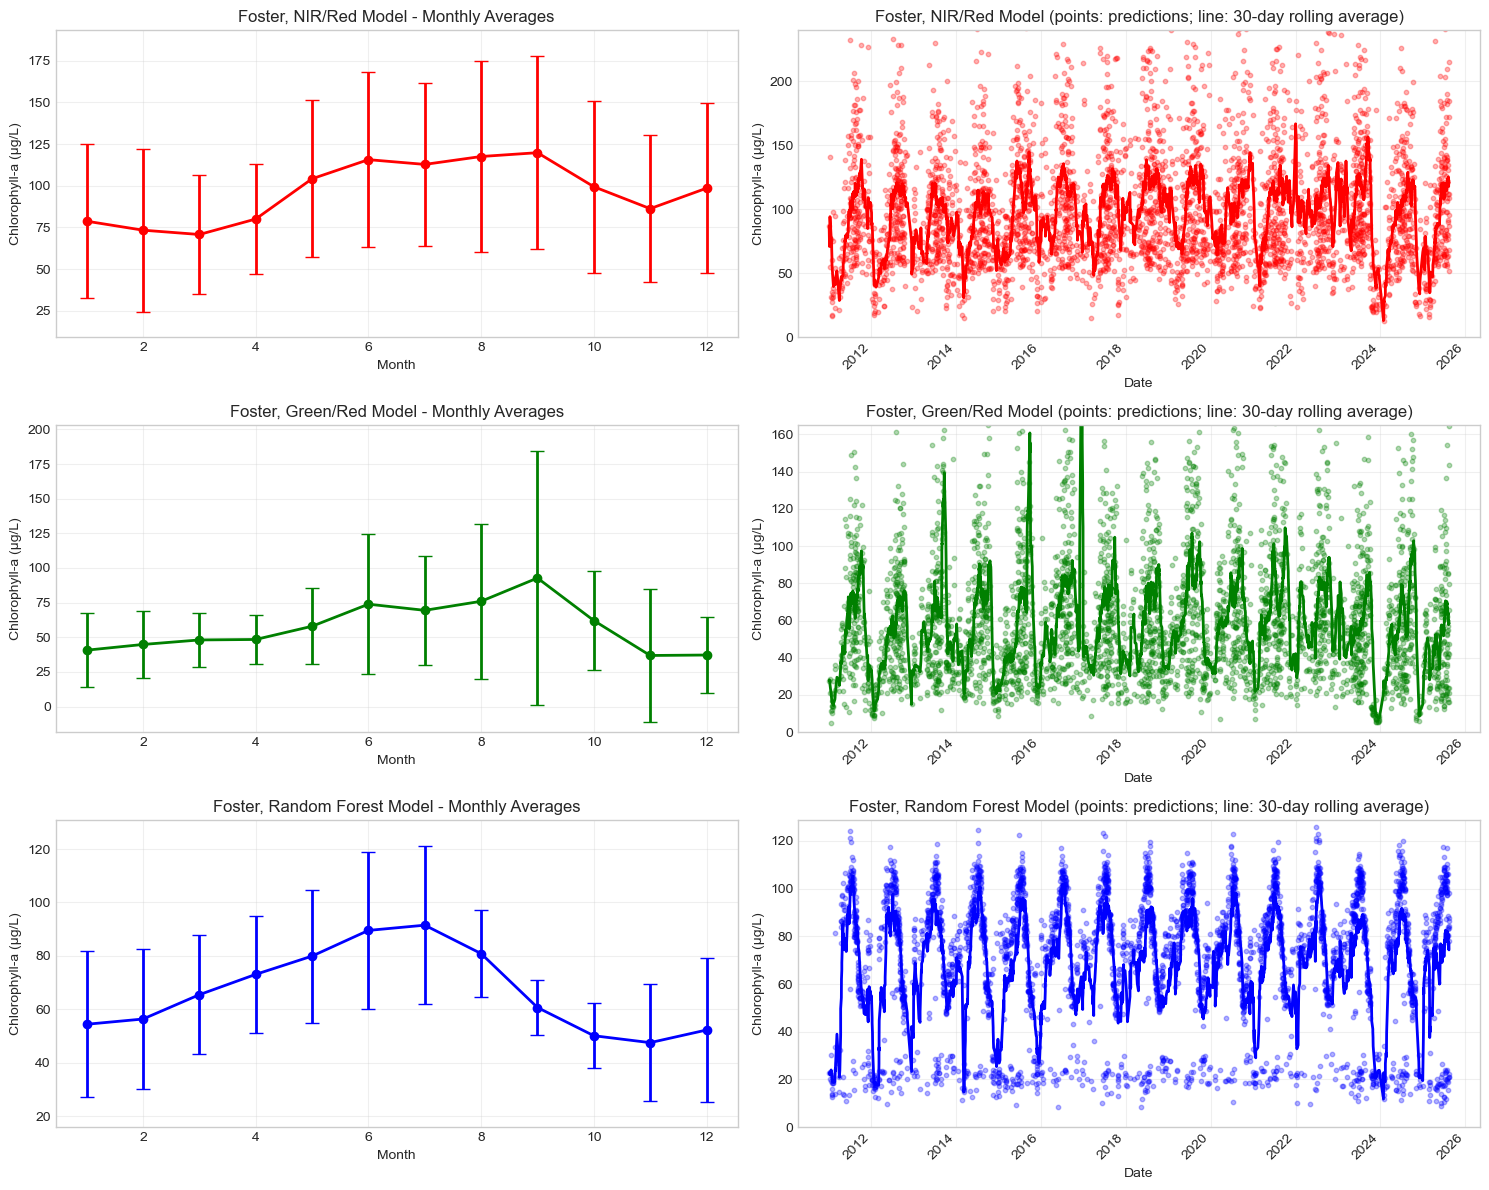


=== Seasonal Pattern Analysis ===

NIR/Red Model:
  Winter: 82.8 ± 49.6 µg/L
  Spring: 87.6 ± 42.5 µg/L
  Summer: 115.2 ± 52.9 µg/L
  Fall: 106.5 ± 55.0 µg/L

Green/Red Model:
  Winter: 41.0 ± 26.3 µg/L
  Spring: 52.3 ± 23.1 µg/L
  Summer: 72.9 ± 48.6 µg/L
  Fall: 71.7 ± 72.4 µg/L

Random Forest Model:
  Winter: 54.5 ± 26.8 µg/L
  Spring: 73.9 ± 24.0 µg/L
  Summer: 87.3 ± 26.1 µg/L
  Fall: 54.6 ± 14.9 µg/L


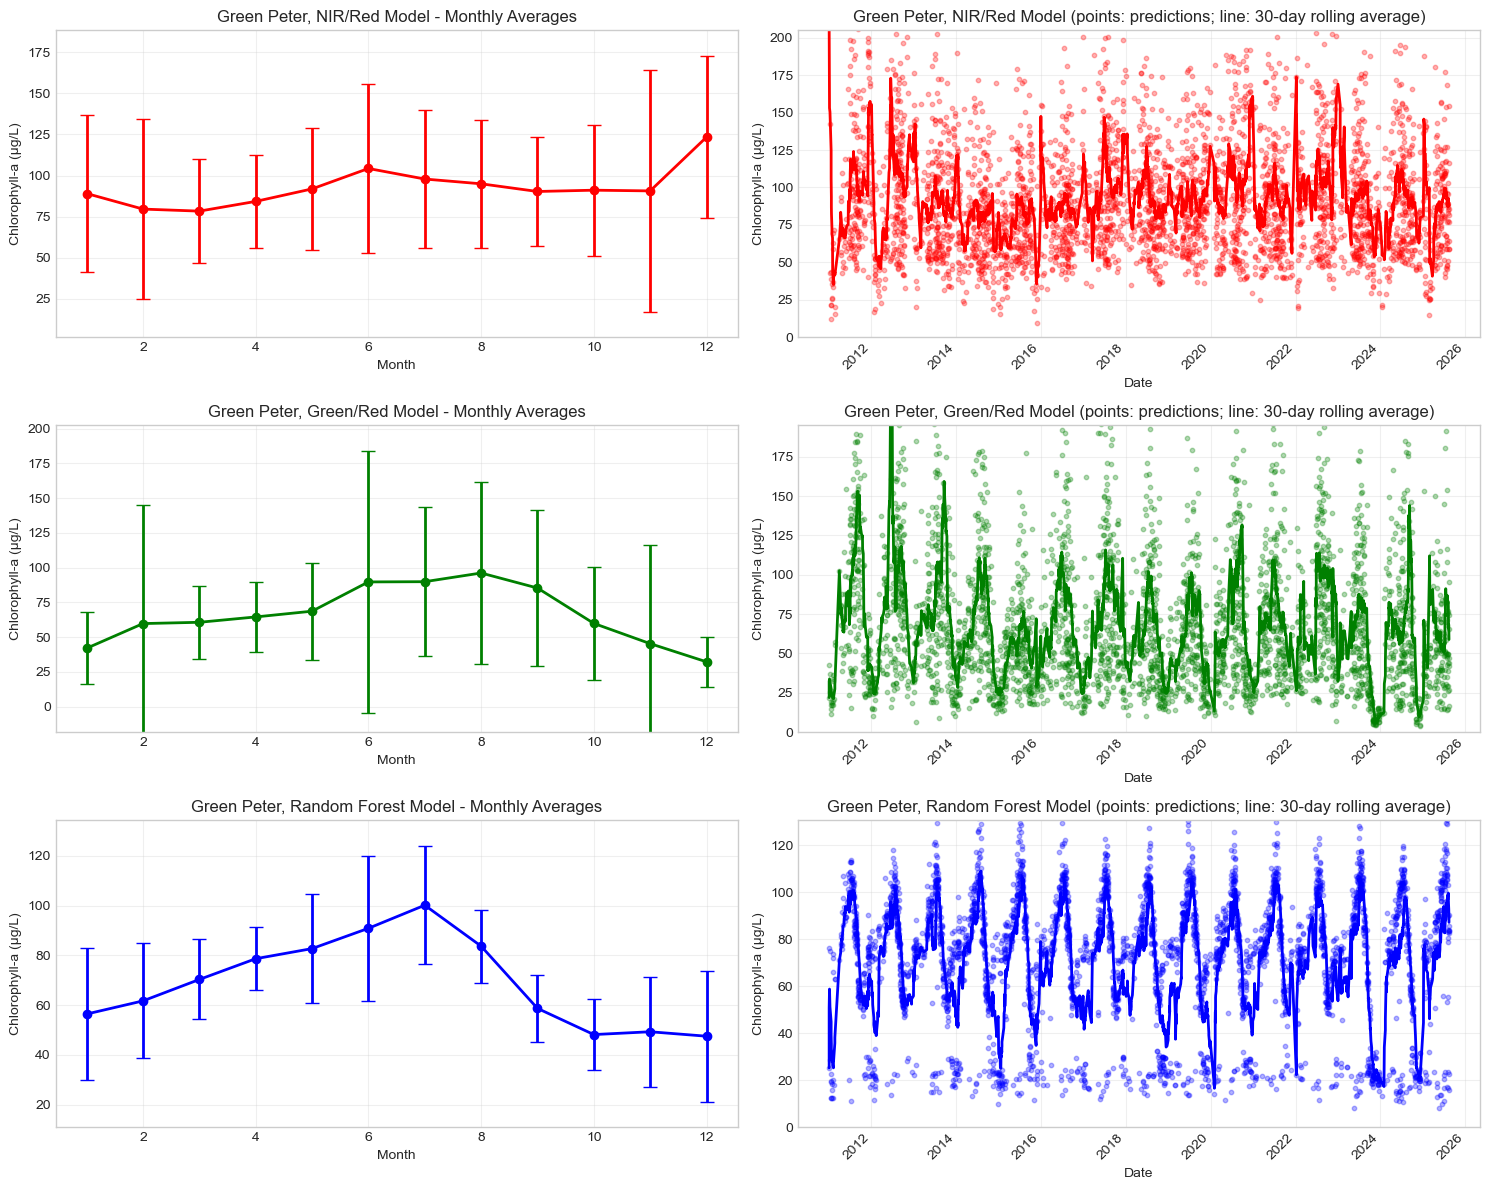


=== Seasonal Pattern Analysis ===

NIR/Red Model:
  Winter: 97.3 ± 53.2 µg/L
  Spring: 86.0 ± 33.5 µg/L
  Summer: 98.4 ± 43.8 µg/L
  Fall: 90.6 ± 47.0 µg/L

Green/Red Model:
  Winter: 43.6 ± 49.0 µg/L
  Spring: 65.3 ± 30.1 µg/L
  Summer: 92.1 ± 69.7 µg/L
  Fall: 67.7 ± 57.7 µg/L

Random Forest Model:
  Winter: 55.1 ± 26.1 µg/L
  Spring: 78.3 ± 18.7 µg/L
  Summer: 92.0 ± 23.7 µg/L
  Fall: 53.0 ± 16.8 µg/L


In [33]:
#===================================================
# Create seasonal comparison for all lakes
#===================================================

for key, values in modis_lakes.items():
    lake_name = values['lake_name']
    modis = values['modis_data']
    plot_seasonal_comparison(modis, lake_name)

## 6. Export Final Predictions

In [ ]:
def export_final_predictions(lake_modis, lake_name, predictions_filename, daily_avg_filename):
    """
    Select best model based on transferability (Green/Red or RF).

    Based on the analysis, Green/Red shows good transferability.
    RF should also work well if it emphasizes green-based features.
    """

    # Export predictions
    export_df = lake_modis[['datetime', 'sensor', 'band1_red', 'band2_nir', 'band4_green', 'chl_green_red', 'chl_rf' ]].copy()

    # Use Green/Red as primary prediction (best transferability)
    export_df['chlorophyll_a_recommended'] = export_df['chl_green_red']

    # Sort and export
    export_df = export_df.sort_values('datetime')
    export_df.to_csv(predictions_filename, index=False)

    # Create daily averages
    daily_avg = export_df.groupby(pd.to_datetime(export_df['datetime']).dt.date).agg({
        'chlorophyll_a_recommended': 'mean',
        'chl_green_red': 'mean',
        'chl_rf': 'mean'
    }).reset_index()
    daily_avg.rename(columns={'index': 'date'}, inplace=True)

    daily_avg.to_csv(daily_avg_filename, index=False)

    print("\n=== Export Complete ===")
    print(f"Full predictions: {predictions_filename} ({len(export_df)} records)")
    print(f"Daily averages: {daily_avg_filename} ({len(daily_avg)} days)")

In [ ]:
#=================================================
# Output the Data
#=================================================

for key, values in modis_lakes.items():
    lake_name = values['lake_name']
    lake_modis = values['modis_data']
    predictions_filename = f'{key}_lake_chlorophyll_transferable_predictions.csv'
    daily_avg_filename = f'{key}_chlorophyll_daily_avg.csv'
    export_final_predictions(lake_modis, lake_name, predictions_filename, daily_avg_filename)

In [ ]:
# Complete Diagnostic Analysis for Optical Distributions
# Run this cell after loading MODIS data but before model training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def diagnose_optical_distributions(ukl_modis, detroit_modis, matched_data=None):
    """
    Diagnose issues with optical property distributions.
    """

    # First, calculate coefficient of variation for quick assessment
    ukl_modis['green_red_calc'] = ukl_modis['band4_green'] / ukl_modis['band1_red']
    detroit_modis['green_red_calc'] = detroit_modis['band4_green'] / detroit_modis['band1_red']

    ukl_cv = ukl_modis['green_red_calc'].std() / ukl_modis['green_red_calc'].mean()
    detroit_cv = detroit_modis['green_red_calc'].std() / detroit_modis['green_red_calc'].mean()

    print("=== Quick Variability Assessment ===")
    print(f"UKL Green/Red CV: {ukl_cv:.3f}")
    print(f"Detroit Green/Red CV: {detroit_cv:.3f}")

    if ukl_cv < 0.15:
        print("\n⚠CRITICAL WARNING: Very low variability in UKL data!")
        print("This will severely limit model transferability.")
        print("STRONG RECOMMENDATION: Use simple Green/Red ratio model only.\n")
    elif ukl_cv < 0.25:
        print("\n⚠WARNING: Limited variability in UKL data.")
        print("Model transferability may be compromised.")
        print("RECOMMENDATION: Proceed with caution, prefer simple models.\n")
    else:
        print("\nGood variability in UKL data for model training.\n")

    # Calculate ratios
    ukl_nir_red = ukl_modis['band2_nir'] / ukl_modis['band1_red']
    ukl_green_red = ukl_modis['band4_green'] / ukl_modis['band1_red']
    
    detroit_nir_red = detroit_modis['band2_nir'] / detroit_modis['band1_red']
    detroit_green_red = detroit_modis['band4_green'] / detroit_modis['band1_red']
    
    # Remove outliers for better visualization
    def remove_outliers(data, n_std=3):
        mean = np.mean(data)
        std = np.std(data)
        return data[(data > mean - n_std*std) & (data < mean + n_std*std)]
    
    ukl_nir_red_clean = remove_outliers(ukl_nir_red)
    ukl_green_red_clean = remove_outliers(ukl_green_red)
    detroit_nir_red_clean = remove_outliers(detroit_nir_red)
    detroit_green_red_clean = remove_outliers(detroit_green_red)
    
    print("=== Data Distribution Diagnostics ===\n")
    
    # Print statistics
    print("Sample sizes:")
    print(f"  UKL total observations: {len(ukl_modis)}")
    print(f"  Detroit total observations: {len(detroit_modis)}")
    if matched_data is not None:
        print(f"  Matched UKL-insitu pairs: {len(matched_data)}")
    
    print("\nNIR/Red ratio statistics:")
    print(f"  UKL: mean={ukl_nir_red.mean():.3f}, std={ukl_nir_red.std():.3f}, "
          f"min={ukl_nir_red.min():.3f}, max={ukl_nir_red.max():.3f}")
    print(f"  Detroit: mean={detroit_nir_red.mean():.3f}, std={detroit_nir_red.std():.3f}, "
          f"min={detroit_nir_red.min():.3f}, max={detroit_nir_red.max():.3f}")
    
    print("\nGreen/Red ratio statistics:")
    print(f"  UKL: mean={ukl_green_red.mean():.3f}, std={ukl_green_red.std():.3f}, "
          f"min={ukl_green_red.min():.3f}, max={ukl_green_red.max():.3f}")
    print(f"  Detroit: mean={detroit_green_red.mean():.3f}, std={detroit_green_red.std():.3f}, "
          f"min={detroit_green_red.min():.3f}, max={detroit_green_red.max():.3f}")
    
    # Create improved visualization
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    # 1. NIR/Red distributions with better binning
    ax = axes[0, 0]
    # Use adaptive binning
    ukl_bins = np.linspace(ukl_nir_red_clean.min(), ukl_nir_red_clean.max(), 30)
    detroit_bins = np.linspace(detroit_nir_red_clean.min(), detroit_nir_red_clean.max(), 50)
    
    ax.hist(ukl_nir_red_clean, bins=ukl_bins, alpha=0.6, label=f'UKL (n={len(ukl_nir_red_clean)})', 
            color='blue', density=True, edgecolor='black')
    ax.hist(detroit_nir_red_clean, bins=detroit_bins, alpha=0.6, label=f'Detroit (n={len(detroit_nir_red_clean)})', 
            color='red', density=True, edgecolor='black')
    ax.set_xlabel('NIR/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title('NIR/Red Distribution (outliers removed)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Green/Red distributions
    ax = axes[0, 1]
    ukl_bins = np.linspace(ukl_green_red_clean.min(), ukl_green_red_clean.max(), 30)
    detroit_bins = np.linspace(detroit_green_red_clean.min(), detroit_green_red_clean.max(), 50)
    
    ax.hist(ukl_green_red_clean, bins=ukl_bins, alpha=0.6, label=f'UKL (n={len(ukl_green_red_clean)})', 
            color='blue', density=True, edgecolor='black')
    ax.hist(detroit_green_red_clean, bins=detroit_bins, alpha=0.6, label=f'Detroit (n={len(detroit_green_red_clean)})', 
            color='red', density=True, edgecolor='black')
    ax.set_xlabel('Green/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title('Green/Red Distribution (outliers removed)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Box plots for better comparison
    ax = axes[1, 0]
    data_nir_red = [ukl_nir_red_clean, detroit_nir_red_clean]
    bp = ax.boxplot(data_nir_red, labels=['UKL', 'Detroit'], patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('NIR/Red Distribution Comparison')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    data_green_red = [ukl_green_red_clean, detroit_green_red_clean]
    bp = ax.boxplot(data_green_red, labels=['UKL', 'Detroit'], patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Green/Red Distribution Comparison')
    ax.grid(True, alpha=0.3)
    
    # 4. Scatter plots to show temporal patterns
    ax = axes[2, 0]
    # Sample data to avoid overplotting
    sample_size = min(1000, len(ukl_modis))
    ukl_sample = ukl_modis.sample(n=sample_size, random_state=42)
    ax.scatter(ukl_sample['datetime'], 
              ukl_sample['band2_nir'] / ukl_sample['band1_red'],
              alpha=0.5, s=10, c='blue', label='UKL')
    
    sample_size = min(1000, len(detroit_modis))
    detroit_sample = detroit_modis.sample(n=sample_size, random_state=42)
    ax.scatter(detroit_sample['datetime'], 
              detroit_sample['band2_nir'] / detroit_sample['band1_red'],
              alpha=0.5, s=10, c='red', label='Detroit')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('Temporal Pattern of NIR/Red Ratios')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax = axes[2, 1]
    ax.scatter(ukl_sample['datetime'], 
              ukl_sample['band4_green'] / ukl_sample['band1_red'],
              alpha=0.5, s=10, c='blue', label='UKL')
    ax.scatter(detroit_sample['datetime'], 
              detroit_sample['band4_green'] / detroit_sample['band1_red'],
              alpha=0.5, s=10, c='red', label='Detroit')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Temporal Pattern of Green/Red Ratios')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('optical_diagnostics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional analysis: Check for data quality issues
    print("\n=== Data Quality Check ===")
    
    # Check for duplicate values
    ukl_nir_unique = len(np.unique(ukl_nir_red))
    ukl_green_unique = len(np.unique(ukl_green_red))
    print(f"\nUnique values in UKL:")
    print(f"  NIR/Red: {ukl_nir_unique} unique values out of {len(ukl_nir_red)} total")
    print(f"  Green/Red: {ukl_green_unique} unique values out of {len(ukl_green_red)} total")
    
    # Check if matched data has better distribution
    if matched_data is not None:
        matched_nir_red = matched_data['band2_nir'] / matched_data['band1_red']
        matched_green_red = matched_data['band4_green'] / matched_data['band1_red']
        
        print(f"\nMatched data statistics:")
        print(f"  NIR/Red: mean={matched_nir_red.mean():.3f}, std={matched_nir_red.std():.3f}")
        print(f"  Green/Red: mean={matched_green_red.mean():.3f}, std={matched_green_red.std():.3f}")
        
        # Plot matched data distribution
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        ax = axes[0]
        ax.hist(matched_nir_red, bins=20, alpha=0.6, color='green', edgecolor='black')
        ax.set_xlabel('NIR/Red Ratio')
        ax.set_ylabel('Count')
        ax.set_title(f'Matched UKL Data NIR/Red (n={len(matched_data)})')
        ax.grid(True, alpha=0.3)
        
        ax = axes[1]
        ax.hist(matched_green_red, bins=20, alpha=0.6, color='green', edgecolor='black')
        ax.set_xlabel('Green/Red Ratio')
        ax.set_ylabel('Count')
        ax.set_title(f'Matched UKL Data Green/Red (n={len(matched_data)})')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'ukl_variability': {
            'nir_red_cv': ukl_nir_red.std() / ukl_nir_red.mean(),
            'green_red_cv': ukl_green_red.std() / ukl_green_red.mean()
        },
        'detroit_variability': {
            'nir_red_cv': detroit_nir_red.std() / detroit_nir_red.mean(),
            'green_red_cv': detroit_green_red.std() / detroit_green_red.mean()
        }
    }


In [ ]:
#===================================================================================
# Run the Diagnostic Analysis - Using Detroit - Mid-Lake and UKL (Calibration Site)
#===================================================================================

#***********************************************************************************
detroit_modis = detroit_mid_lake_modis.copy()
#***********************************************************************************

print("Running comprehensive diagnostic analysis...\n")


# Run full diagnostics (this will run the function if matched_data exists)
if 'matched_data' in locals():
    diagnostics = diagnose_optical_distributions(ukl_modis, detroit_modis, matched_data)
else:
    print("Note: Running diagnostics without matched data (will be limited)")
    diagnostics = diagnose_optical_distributions(ukl_modis, detroit_modis)

# Print final recommendations
print("\n=== FINAL RECOMMENDATIONS ===")
if ukl_cv < 0.15:
    print("1. DO NOT use NIR/Red model - it will fail catastrophically")
    print("2. Use simple Green/Red ratio model as primary approach")
    print("3. If using Random Forest, heavily weight Green/Red features")
    print("4. Apply strict bounds to predictions based on UKL training range")
    print("5. Flag all predictions outside UKL's optical range as uncertain")
else:
    print("1. Green/Red model should work well")
    print("2. Random Forest with green-focused features is viable")
    print("3. Avoid or down-weight NIR/Red features")
    print("4. Monitor predictions for unrealistic values")

# Save diagnostics for reference
diagnostic_summary = {
    'ukl_cv': ukl_cv,
    'detroit_cv': detroit_cv,
    'variability_ratio': detroit_cv / ukl_cv,
    'recommendation': 'Use Green/Red only' if ukl_cv < 0.15 else 'Proceed with caution'
}

print(f"\nVariability ratio (Detroit/UKL): {diagnostic_summary['variability_ratio']:.2f}")
print("Higher ratios indicate greater optical diversity in Detroit vs UKL")